### Snow Model Forcing
#### `3_create_wind_ninja_input.ipynb` 

Notebook contents 
* for now, I've dropped code here to create wind ninja input data files (untested, need to finish)
* notebook is a copy from `juneau_data_analysis > 6d_create_wind_ninja_input.ipynb` script to get it cleaned up in the forcing data repo instead 

created by Cassie Lumbrazo\
last updated: Oct 2025\
run location: UAS linux\
python environment: **rasterio**

In [13]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

from rasterio.warp import transform_bounds

from scipy import ndimage

from rasterio.fill import fillnodata

from osgeo import gdal # installed gdal into `rasterio` conda env
import shutil
from pyproj import Transformer

<xarray.Dataset> Size: 32MB
Dimensions:                  (time: 4722, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 38kB 2024-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 38kB ...
    valid_time               (time) datetime64[ns] 38kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Dimensions without coordinates: y, x
Data variables:
    u10                      (time, y, x) float32 8MB -4.269 -2.144 ... 0.7717
    v10                      (time, y, x) float32 8MB -3.529 -3.779 ... 1.997
    wind_speed               (time, y, x) float32 8MB 5.539 4.345 ... 2.141
    wind_direction           (time, y, x) float32 8MB 230.4 209.6 ... 21.13
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

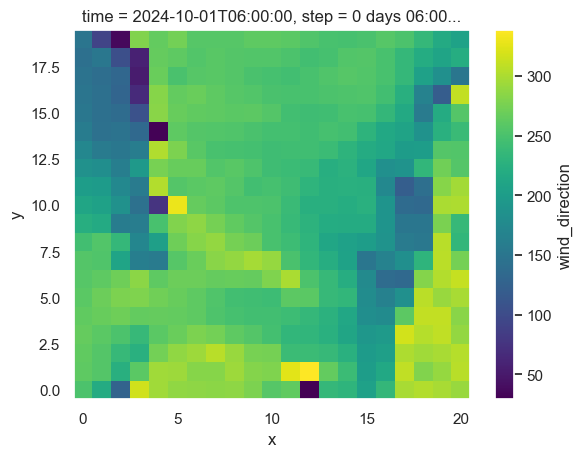

In [14]:
filepath = "/hdd/snow_hydrology/hrrrak/netcdf/"
filename = "hrrrak_merged_grib_f567_WY2025_test1.nc"

# load data
ds_hrrr = xr.open_dataset(filepath + filename)
# ds_hrrr = ds_hrrr.rio.write_crs('EPSG:32608', inplace=True)  # EPSG:32608 is the UTM zone 8N, which is the zone for the Powderpatch area
ds_hrrr = ds_hrrr.rio.write_crs('EPSG:4326', inplace=True)  # the data is in lat/lon

# calculate wind speed from u and v components
ds_hrrr['wind_speed'] = np.sqrt(ds_hrrr['u10']**2 + ds_hrrr['v10']**2)

# implemented, 
ds_hrrr["wind_direction"] = (180 * np.arctan2(ds_hrrr["u10"], ds_hrrr["v10"]) / np.pi)
ds_hrrr["wind_direction"] = (ds_hrrr["wind_direction"]+360) % 360 # convert to compass bearing 
ds_hrrr["wind_direction"][1].plot()

# Now we want to save a very simple version of a dataset, with only the wind speed and direction, for use in WindNinja.
# ds_hrrr_wind = ds_hrrr[["wind_speed", "wind_direction"]].copy()
ds_hrrr_wind = ds_hrrr[["u10", "v10", "wind_speed", "wind_direction"]].copy()
ds_hrrr_wind

Now, there is some dimension stuff to do

In [15]:
ds = ds_hrrr_wind.copy(deep=True) 

# Step 1: Rename dimensions if needed and set spatial dims
ds = ds.rename({'longitude': 'x', 'latitude': 'y'})
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')

# Step 2: Extract 1D x and y coordinates from the 2D grid
# Grab 1D x and y
x_1d = ds['x'].isel(y=0)  # same x values across rows
y_1d = ds['y'].isel(x=0)  # same y values down columns

# Assign 1D coords to the dataset
ds = ds.assign_coords(x=x_1d, y=y_1d)

# Step 3: Drop the 2D coords from the coordinate system
ds = ds.drop_vars(['x', 'y'])  # remove old 2D variables
ds = ds.set_coords([])         # ensure no unexpected spatial coords

# Step 4: Reassign the cleaned 1D coords
ds = ds.assign_coords({'x': x_1d, 'y': y_1d})

# Step 5: Now, reproject to UTM
# Now reproject to UTM
ds_utm = ds.rio.reproject("EPSG:32608")

In [16]:
# Transformer from WGS84 (lat/lon) to UTM Zone 8N
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)

# Input in (lon, lat) order for Powderpatch area
xmin_lon, ymin_lat = -134.594876, 58.238519
xmax_lon, ymax_lat = -134.445151, 58.308517

## This bounding box is for the general Juneau region
# xmin_lon, xmax_lon = -134.964, -133.893
# ymin_lat, ymax_lat = 58.077, 58.603

# Convert all corners
xmin, ymin = transformer.transform(xmin_lon, ymin_lat)
xmax, ymax = transformer.transform(xmax_lon, ymax_lat)

print(f"UTM BBox: xmin={xmin:.2f}, xmax={xmax:.2f}, ymin={ymin:.2f}, ymax={ymax:.2f}")

# clip everything
ds_utm_clipped = ds_utm.rio.clip_box(minx=xmin, miny=ymin, maxx=xmax, maxy=ymax)

UTM BBox: xmin=523787.03, xmax=532513.90, ymin=6455337.22, ymax=6463193.11


In [18]:
# now save this to a new netcdf file for later use
output_nc_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_powderpatch_utm.nc"
ds_utm_clipped.to_netcdf(output_nc_file)

Now, final step. ascii files

In [23]:
# now, cut the netcdf to just 2 days of data for testing
time_start = np.datetime64('2024-10-01T00:00:00')
time_end = np.datetime64('2024-10-02T00:00:00')
ds_utm_clipped = ds_utm_clipped.sel(time=slice(time_start, time_end))

# and save
output_nc_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_powderpatch_utm_2daysonly.nc"
ds_utm_clipped.to_netcdf(output_nc_file)

### Clip the DEM to an even smaller area 

✅ Step 1: Convert NetCDF to .asc files per timestep

Each .asc will need a header like before, 

I’ll write a function that:

Reads each timestep of wind_speed and wind_direction.

Saves them to .asc files with the timestamp in the filename.

Returns a list of generated filenames.

✅ Step 2: Run WindNinja CLI for each timestep

We'll write a script to:

Copy the base config.

Update the input_wind_filename in the config to the .asc just made.

Run WindNinja using subprocess.

✅ Step 3: Zip results per batch

After WindNinja finishes, we zip the result directories.

### Dropping code for now, come back to this

Here's your pipeline script that:

Extracts wind data from a NetCDF timeseries.

Converts each timestep into .asc files for WindNinja.

Runs WindNinja for each timestep using a config template.

Zips all output folders into one archive.

In [25]:
import os
import xarray as xr
import numpy as np
import subprocess
from zipfile import ZipFile
from datetime import datetime

# ==== USER SETTINGS (EDIT HERE) ====
# NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1.nc"
# NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_powderpatch_utm.nc"
NETCDF_FILE = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_powderpatch_utm_2daysonly.nc" # this is just a day or two of data for testing
DEM_FILE = "/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_10m_UTM_clip_powderpatch_filled_gdal.tif"
WINDNINJA_CONFIG = "/hdd/snow_hydrology/wind_ninja/test4/test4_config_template.cfg" # this is the one with placeholders
OUTPUT_DIR = "/hdd/snow_hydrology/wind_ninja/test4/output"
TMP_ASC_DIR = "/hdd/snow_hydrology/wind_ninja/test4/input/ascii_inputs"
VARIABLES = {
    "speed": "wind_speed",
    "direction": "wind_direction"
}
XLLCORNER = 2782000  # change as needed
YLLCORNER = 1182000  # change as needed
CELLSIZE = 100
NODATA_VALUE = -9999
# ===================================

def write_asc(data: np.ndarray, output_path: str, xll: float, yll: float, cellsize: float, nodata: float):
    nrows, ncols = data.shape
    header = (
        f"ncols         {ncols}\n"
        f"nrows         {nrows}\n"
        f"xllcorner     {xll}\n"
        f"yllcorner     {yll}\n"
        f"cellsize      {cellsize}\n"
        f"NODATA_value  {nodata}\n"
    )
    with open(output_path, 'w') as f:
        f.write(header)
        for row in data:
            row_str = '\t'.join(f"{val:.2f}" if not np.isnan(val) else str(nodata) for val in row)
            f.write(row_str + '\n')

# ===================================

def generate_ascii_files(ds):
    os.makedirs(TMP_ASC_DIR, exist_ok=True)
    ascii_file_pairs = []

    # Projection string for .prj files (UTM Zone 8N)
    prj_contents = (
        'PROJCS["WGS_1984_UTM_Zone_8N",'
        'GEOGCS["GCS_WGS_1984",'
        'DATUM["D_WGS_1984",'
        'SPHEROID["WGS_1984",6378137.0,298.257223563]],'
        'PRIMEM["Greenwich",0.0],'
        'UNIT["Degree",0.0174532925199433]],'
        'PROJECTION["Transverse_Mercator"],'
        'PARAMETER["False_Easting",500000.0],'
        'PARAMETER["False_Northing",0.0],'
        'PARAMETER["Central_Meridian",-135.0],'
        'PARAMETER["Scale_Factor",0.9996],'
        'PARAMETER["Latitude_Of_Origin",0.0],'
        'UNIT["Meter",1.0]]'
    )

    for i, t in enumerate(ds.time):
        timestamp = pd.to_datetime(str(t.values)).strftime("%Y%m%d_%H%M")
        speed_2d = ds[VARIABLES["speed"]].isel(time=i).values
        dir_2d = ds[VARIABLES["direction"]].isel(time=i).values

        speed_path = os.path.join(TMP_ASC_DIR, f"wind_speed_{timestamp}.asc")
        dir_path = os.path.join(TMP_ASC_DIR, f"wind_dir_{timestamp}.asc")

        # Write ASC files
        write_asc(speed_2d, speed_path, XLLCORNER, YLLCORNER, CELLSIZE, NODATA_VALUE)
        write_asc(dir_2d, dir_path, XLLCORNER, YLLCORNER, CELLSIZE, NODATA_VALUE)

        # Write corresponding PRJ files
        with open(speed_path.replace(".asc", ".prj"), 'w') as f:
            f.write(prj_contents)
        with open(dir_path.replace(".asc", ".prj"), 'w') as f:
            f.write(prj_contents)

        ascii_file_pairs.append((timestamp, speed_path, dir_path))

    return ascii_file_pairs

# ===================================

def run_windninja(speed_path, dir_path, timestamp):
    output_subdir = os.path.join(OUTPUT_DIR, f"windninja_{timestamp}")
    os.makedirs(output_subdir, exist_ok=True)

    config_path = os.path.join(output_subdir, f"config_{timestamp}.cfg")
    with open(WINDNINJA_CONFIG, 'r') as f:
        config = f.read()

    config = config.replace("INPUT_SPEED_FILE", speed_path)
    config = config.replace("INPUT_DIR_FILE", dir_path)
    config = config.replace("INPUT_DEM_FILE", DEM_FILE)
    config = config.replace("OUTPUT_PATH", output_subdir)

    with open(config_path, 'w') as f:
        f.write(config)

    # Run WindNinja via Docker
    docker_command = [
        "docker", "run", "--rm",
        "-v", "/hdd:/hdd",
        "windninja:latest",
        "WindNinja_cli", config_path
    ]
    subprocess.run(docker_command, check=True)

# ===================================

def zip_outputs():
    zipf = ZipFile(f"{OUTPUT_DIR}.zip", 'w')
    for root, _, files in os.walk(OUTPUT_DIR):
        for file in files:
            filepath = os.path.join(root, file)
            zipf.write(filepath, os.path.relpath(filepath, OUTPUT_DIR))
    zipf.close()

# ===================================

def main():
    ds = xr.open_dataset(NETCDF_FILE)
    ascii_files = generate_ascii_files(ds)
    for timestamp, speed, direction in ascii_files:
        print(f"Processing timestep {timestamp}")
        run_windninja(speed, direction, timestamp)
    zip_outputs()
    print("All done. Output zipped.")

if __name__ == "__main__":
    import pandas as pd
    main()

Processing timestep 20241001_0500


ERROR 1: Connection timed out after 5001 milliseconds


Run 0: Reading elevation file...
Run 0: Run number 0 started with 15 threads.
Run 0: Generating mesh...
Run 0: Initializing flow...
Exception caught: The input speed and direction grids do not completely overlap the DEM.
Exception caught: The input speed and direction grids do not completely overlap the DEM.


CalledProcessError: Command '['docker', 'run', '--rm', '-v', '/hdd:/hdd', 'windninja:latest', 'WindNinja_cli', '/hdd/snow_hydrology/wind_ninja/test4/output/windninja_20241001_0500/config_20241001_0500.cfg']' returned non-zero exit status 255.